# MAPL+ | Exploratory Data Analysis
**Goal:** Understand data structure, quality, and early signals of product cannibalization

**Business Questions:**
1. Bagaimana distribusi transaksi, revenue, dan promo antar SKU dan brand?
2. Apakah ada pola promo yang terjadi bersamaan antar SKU dalam brand yang sama?
3. SKU mana saja yang menjadi kandidat kuat pasangan cannibalization?

## 0. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# plot style
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11

BRAND_COLORS = {
    'Richeese' : '#E8472A',
    'Richoco'  : '#6B3FA0',
    'Nextar'   : '#1A7FC1'
}

print('✅ Libraries loaded')

✅ Libraries loaded


## 1. Load & Merge Data

In [3]:
df1 = pd.read_csv('../data/transaction_1.csv', index_col=0)
df2 = pd.read_csv('../data/transaction_2.csv', index_col=0)

print('=== Shape Masing-Masing Dataset ===')
print(f'Transaction 1 : {df1.shape[0]:,} rows x {df1.shape[1]} cols')
print(f'Transaction 2 : {df2.shape[0]:,} rows x {df2.shape[1]} cols')

print('\n=== Date Range ===')
print(f'Transaction 1 : {df1["DateTime"].min()} → {df1["DateTime"].max()}')
print(f'Transaction 2 : {df2["DateTime"].min()} → {df2["DateTime"].max()}')

print('\n=== Columns Match ===')
print('Same columns?', df1.columns.tolist() == df2.columns.tolist())

print('\n=== Overlapping TransactionIDs ===')
overlap = set(df1['TransactionID']) & set(df2['TransactionID'])
print(f'{len(overlap)} overlapping ID → aman digabung')

=== Shape Masing-Masing Dataset ===
Transaction 1 : 250,001 rows x 15 cols
Transaction 2 : 250,001 rows x 15 cols

=== Date Range ===
Transaction 1 : 2025-05-01 09:01:41 → 2025-10-30 20:56:19
Transaction 2 : 2025-05-01 09:00:21 → 2025-10-30 20:56:20

=== Columns Match ===
Same columns? True

=== Overlapping TransactionIDs ===
1 overlapping ID → aman digabung


In [4]:
# merge & parse datetime
df = pd.concat([df1, df2], ignore_index=True)
df['DateTime'] = pd.to_datetime(df['DateTime'])
df['Date']     = df['DateTime'].dt.date
df['Week']     = df['DateTime'].dt.to_period('W')
df['Month']    = df['DateTime'].dt.to_period('M')

print(f'✅ Combined shape: {df.shape[0]:,} rows x {df.shape[1]} cols')
df.head()

✅ Combined shape: 500,002 rows x 18 cols


,TransactionID,DateTime,Date_Key,Branch,Customer_ID,SKU_ID,SKU,Brand,SKU_Category,Qty,NormalPrice,DiscountedPrice,DiscountPercentage,Total_Price,Promo_Category,Date,Week,Month
0,T024913,2025-09-26 15:16:25,20250926,Surabaya,C40615,S007,Richeese Siip Keju 20g,Richeese,Extruded Snack,4,3000.0,3000.0,0.00,12000.0,No Promo,2025-09-26,2025-09-22/2025-09-28,2025-09
1,T043161,2025-08-03 16:55:20,20250803,Bandung,C04119,S020,Richeese Mi Instan Goreng,Richeese,Mi Instan,3,3500.0,3300.0,0.05,9900.0,Promo Normal,2025-08-03,2025-07-28/2025-08-03,2025-08
2,T043161,2025-08-03 16:55:20,20250803,Bandung,C04119,S012,Nabati Biskuit Rasa Cokelat,Richoco,Biskuit,1,5000.0,4800.0,0.05,4800.0,Promo Normal,2025-08-03,2025-07-28/2025-08-03,2025-08
3,T089523,2025-09-18 15:11:42,20250918,Jakarta,C49209,S002,Richoco Wafer Cokelat 50g,Richoco,Wafer,2,6100.0,5800.0,0.05,11600.0,Promo Normal,2025-09-18,2025-09-15/2025-09-21,2025-09
4,T130311,2025-09-19 09:49:08,20250919,Bandung,C42176,S001,Richeese Wafer Keju 50g,Richeese,Wafer,5,6100.0,5800.0,0.05,29000.0,Promo Bundling,2025-09-19,2025-09-15/2025-09-21,2025-09


## 2. Data Quality Check

In [5]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Tidak ada missing values ✅')

print('\n=== Duplicate Rows ===')
dupes = df.duplicated().sum()
print(f'{dupes} duplicate rows', '✅' if dupes == 0 else '⚠️ perlu di-drop')

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== Negative / Zero Values ===')
print(f'Qty <= 0        : {(df["Qty"] <= 0).sum()}')
print(f'NormalPrice <= 0: {(df["NormalPrice"] <= 0).sum()}')
print(f'Total_Price <= 0: {(df["Total_Price"] <= 0).sum()}')

=== Missing Values ===
Tidak ada missing values ✅

=== Duplicate Rows ===
0 duplicate rows ✅

=== Data Types ===
TransactionID                 object
DateTime              datetime64[ns]
Date_Key                       int64
Branch                        object
Customer_ID                   object
SKU_ID                        object
SKU                           object
Brand                         object
SKU_Category                  object
Qty                            int64
NormalPrice                  float64
DiscountedPrice              float64
DiscountPercentage           float64
Total_Price                  float64
Promo_Category                object
Date                          object
Week                   period[W-SUN]
Month                      period[M]
dtype: object

=== Negative / Zero Values ===
Qty <= 0        : 0
NormalPrice <= 0: 0
Total_Price <= 0: 0


In [6]:
print('=== SKU Landscape ===')
sku_info = df[['SKU_ID','SKU','Brand','SKU_Category']].drop_duplicates().sort_values(['Brand','SKU_Category'])
print(sku_info.to_string(index=False))

print('\n=== SKU Count per Brand ===')
print(df.groupby('Brand')['SKU'].nunique())

print('\n=== Branches ===')
print(df['Branch'].value_counts())

=== SKU Landscape ===
SKU_ID                               SKU    Brand   SKU_Category
  S006             Nextar Nastar Pie 30g   Nextar        Kue/Pie
  S017          Nextar Choco Delight 40g   Nextar        Kue/Pie
  S018          Nextar Pineapple Pie 30g   Nextar        Kue/Pie
  S005           Nextar Brownies Pie 40g   Nextar        Kue/Pie
  S011        Nabati Biskuit Rasa Kelapa Richeese        Biskuit
  S007            Richeese Siip Keju 20g Richeese Extruded Snack
  S019    Richeese Siip Jagung Bakar 20g Richeese Extruded Snack
  S020         Richeese Mi Instan Goreng Richeese      Mi Instan
  S010     Richeese Mi Instan Ramen Keju Richeese      Mi Instan
  S009     Richeese Mi Instan Keju Pedas Richeese      Mi Instan
  S013      Nabati Drinko Richeese 150ml Richeese        Minuman
  S001           Richeese Wafer Keju 50g Richeese          Wafer
  S015      Richeese Wafer Pink Lava 50g Richeese          Wafer
  S003   Richeese Wafer Keju 10g Renceng Richeese          Wafer
  S

## 3. Weekly Aggregation

In [19]:
# Step 1: hitung berapa HARI UNIK ada transaksi per minggu
daily_check = df.groupby(['Week', 'Date']).size().reset_index()
daily_check.columns = ['Week', 'Date', 'txn_count']

days_per_week = daily_check.groupby('Week')['Date'].count().reset_index()
days_per_week.columns = ['Week', 'days_with_data']

# Step 2: minggu penuh = tepat 7 hari ada transaksi
full_weeks = days_per_week[days_per_week['days_with_data'] == 7]['Week']

# OUTPUT
print(days_per_week.to_string(index=False))
print()
print(f'Minggu penuh (7 hari)    : {len(full_weeks)}')
print(f'Minggu tidak penuh       : {(days_per_week["days_with_data"] < 7).sum()}')
print()
print('=== Minggu yang di-EXCLUDE ===')
print(days_per_week[days_per_week['days_with_data'] < 7].to_string(index=False))

                 Week  days_with_data
2025-04-28/2025-05-04               4
2025-05-05/2025-05-11               7
2025-05-12/2025-05-18               7
2025-05-19/2025-05-25               7
2025-05-26/2025-06-01               6
2025-06-02/2025-06-08               7
2025-06-09/2025-06-15               7
2025-06-16/2025-06-22               7
2025-06-23/2025-06-29               7
2025-06-30/2025-07-06               7
2025-07-07/2025-07-13               7
2025-07-14/2025-07-20               7
2025-07-21/2025-07-27               7
2025-07-28/2025-08-03               6
2025-08-04/2025-08-10               7
2025-08-11/2025-08-17               7
2025-08-18/2025-08-24               7
2025-08-25/2025-08-31               6
2025-09-01/2025-09-07               7
2025-09-08/2025-09-14               7
2025-09-15/2025-09-21               7
2025-09-22/2025-09-28               7
2025-09-29/2025-10-05               7
2025-10-06/2025-10-12               7
2025-10-13/2025-10-19               7
2025-10-20/2

In [8]:
# cek minggu penuh (7 hari)
daily_check  = df.groupby(['Week','Date']).size().reset_index()
days_per_week = daily_check.groupby('Week')['Date'].count().reset_index()
days_per_week.columns = ['Week','days_with_data']
full_weeks = days_per_week[days_per_week['days_with_data'] == 7]['Week']
print(f'Minggu penuh (7 hari): {len(full_weeks)} minggu')
print(f'Minggu tidak penuh   : {len(days_per_week) - len(full_weeks)} minggu (akan di-exclude)')

# filter ke minggu penuh
df_full = df[df['Week'].isin(full_weeks)].copy()

# weekly aggregation
weekly = df_full.groupby(['Week','SKU_ID','SKU','Brand','SKU_Category']).agg(
    total_qty        = ('Qty', 'sum'),
    avg_normal_price = ('NormalPrice', 'mean'),
    avg_disc_price   = ('DiscountedPrice', 'mean'),
    avg_discount_pct = ('DiscountPercentage', 'mean'),
    total_revenue    = ('Total_Price', 'sum'),
    promo_txn_count  = ('Promo_Category', lambda x: (x != 'No Promo').sum()),
    total_txn_count  = ('Promo_Category', 'count'),
    promo_type       = ('Promo_Category', lambda x: x[x != 'No Promo'].mode()[0]
                        if (x != 'No Promo').any() else 'No Promo')
).reset_index()

weekly['promo_ratio'] = weekly['promo_txn_count'] / weekly['total_txn_count']
weekly['promo_flag']  = (weekly['promo_ratio'] > 0.5).astype(int)

print(f'\n✅ Weekly shape: {weekly.shape}')
weekly.head()

Minggu penuh (7 hari): 22 minggu
Minggu tidak penuh   : 5 minggu (akan di-exclude)

✅ Weekly shape: (440, 15)


,Week,SKU_ID,SKU,Brand,SKU_Category,total_qty,avg_normal_price,avg_disc_price,avg_discount_pct,total_revenue,promo_txn_count,total_txn_count,promo_type,promo_ratio,promo_flag
0,2025-05-05/2025-05-11,S001,Richeese Wafer Keju 50g,Richeese,Wafer,5073,5500.0,5190.106635,0.054058,26305600.0,1316,1688,Promo Bundling,0.779621,1
1,2025-05-05/2025-05-11,S002,Richoco Wafer Cokelat 50g,Richoco,Wafer,2423,5500.0,5189.093137,0.056924,12587800.0,448,816,Promo Normal,0.549020,1
2,2025-05-05/2025-05-11,S003,Richeese Wafer Keju 10g Renceng,Richeese,Wafer,2360,10000.0,9438.540333,0.056146,22273500.0,414,781,Promo Normal,0.530090,1
3,2025-05-05/2025-05-11,S004,Richoco Wafer Cokelat 10g Renceng,Richoco,Wafer,2478,10000.0,9406.905055,0.059309,23271000.0,439,811,Promo Normal,0.541307,1
4,2025-05-05/2025-05-11,S005,Nextar Brownies Pie 40g,Nextar,Kue/Pie,2272,7000.0,6632.266667,0.051067,15062000.0,366,750,Promo Normal,0.488000,0


## 4. Revenue & Sales Trend

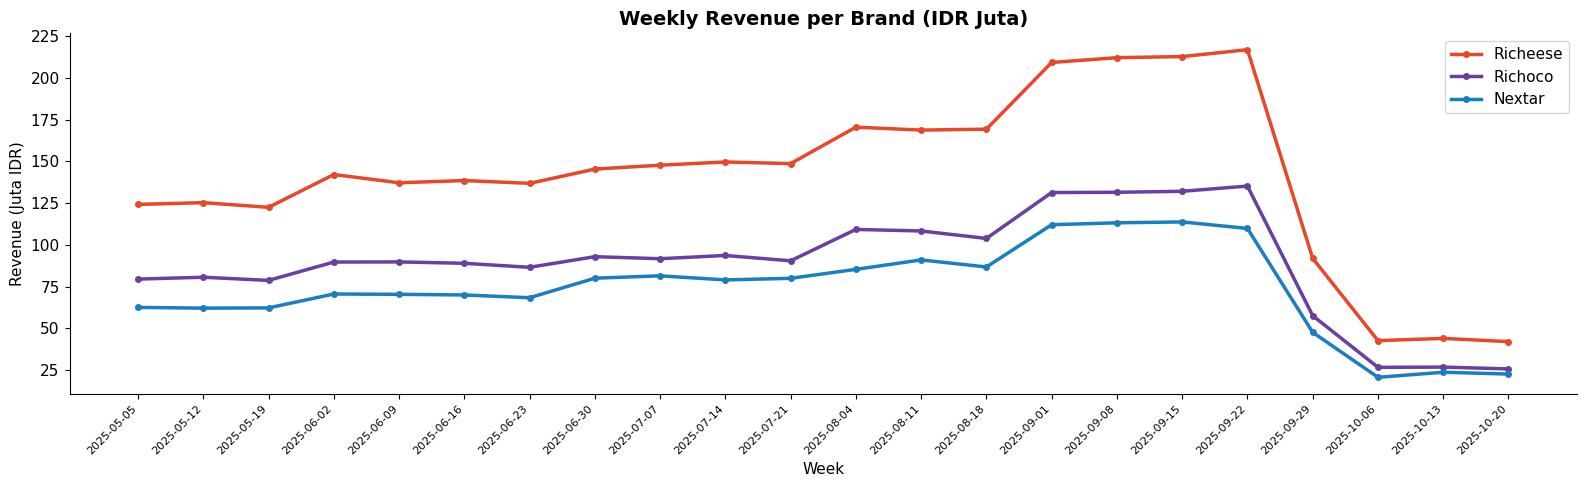

In [9]:
# --- 4A. Weekly Revenue per Brand ---
rev_brand = weekly.groupby(['Week','Brand'])['total_revenue'].sum().reset_index()
rev_brand['Week_str'] = rev_brand['Week'].astype(str).str[:10]

fig, ax = plt.subplots(figsize=(16, 5))
for brand, color in BRAND_COLORS.items():
    d = rev_brand[rev_brand['Brand'] == brand]
    ax.plot(d['Week_str'], d['total_revenue'] / 1e6,
            label=brand, color=color, linewidth=2.5, marker='o', markersize=4)

ax.set_title('Weekly Revenue per Brand (IDR Juta)', fontsize=14, fontweight='bold')
ax.set_xlabel('Week')
ax.set_ylabel('Revenue (Juta IDR)')
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

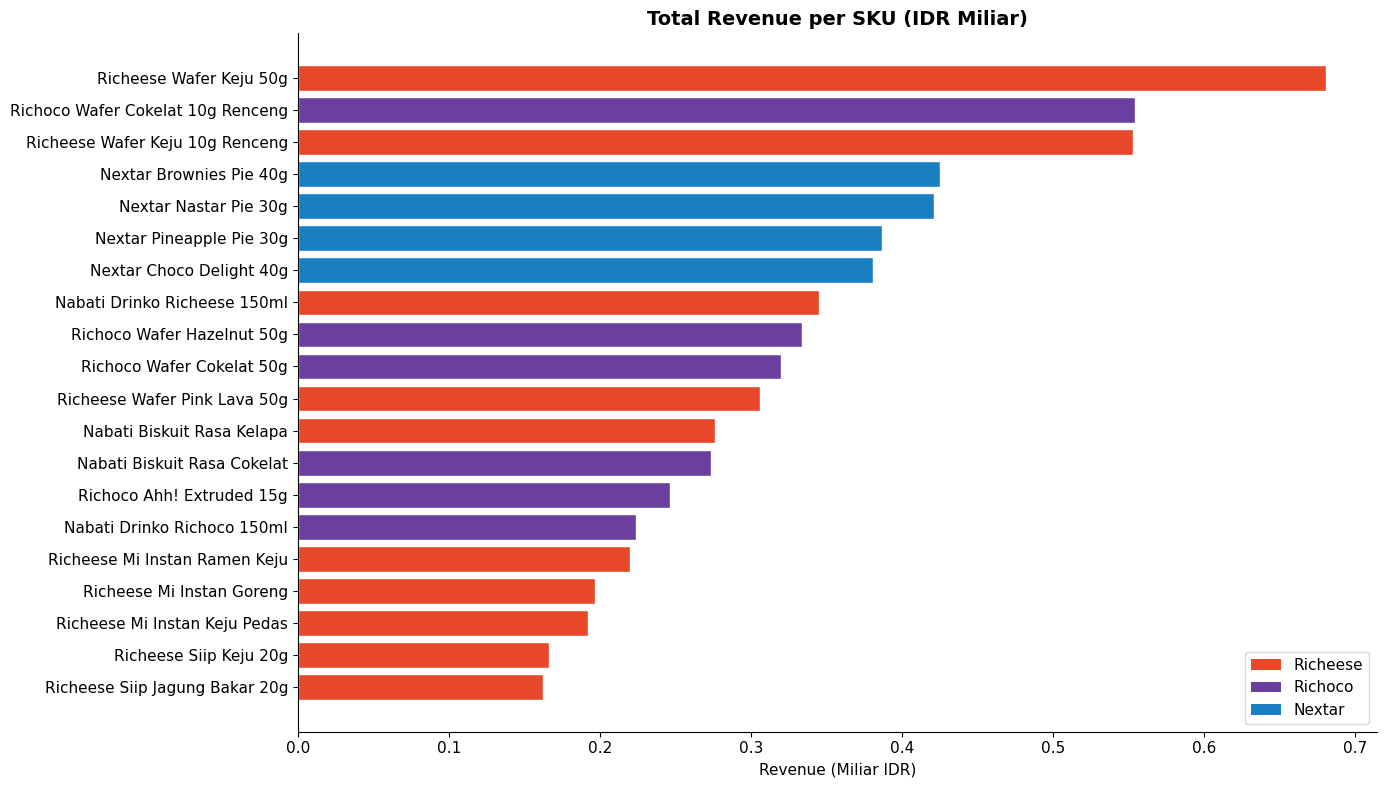

In [10]:
# --- 4B. Total Revenue per SKU (Bar) ---
rev_sku = weekly.groupby(['SKU','Brand'])['total_revenue'].sum().reset_index()
rev_sku = rev_sku.sort_values('total_revenue', ascending=True)
colors  = [BRAND_COLORS[b] for b in rev_sku['Brand']]

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(rev_sku['SKU'], rev_sku['total_revenue'] / 1e9, color=colors, edgecolor='white')
ax.set_title('Total Revenue per SKU (IDR Miliar)', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue (Miliar IDR)')

# legend brand
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=b) for b, c in BRAND_COLORS.items()]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

## 5. Promo Analysis

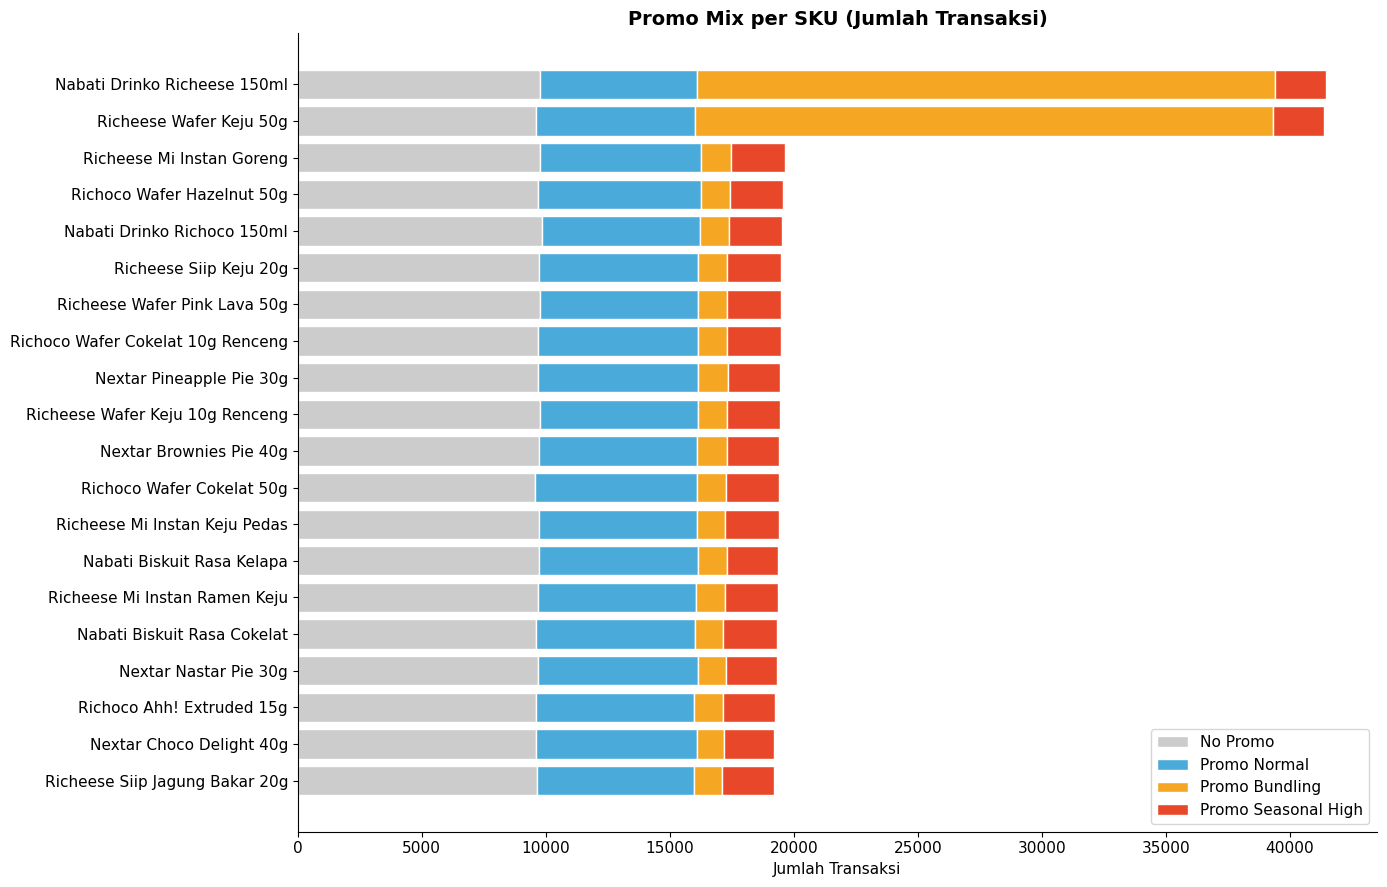

In [11]:
# --- 5A. Promo Mix per SKU (Stacked Bar) ---
promo_mix = df_full.groupby(['SKU','Promo_Category']).size().reset_index(name='count')
promo_pivot = promo_mix.pivot(index='SKU', columns='Promo_Category', values='count').fillna(0)

# sort by total
promo_pivot['_total'] = promo_pivot.sum(axis=1)
promo_pivot = promo_pivot.sort_values('_total').drop(columns='_total')

promo_colors = {
    'No Promo'           : '#CCCCCC',
    'Promo Normal'       : '#4AABDB',
    'Promo Bundling'     : '#F5A623',
    'Promo Seasonal High': '#E8472A'
}

fig, ax = plt.subplots(figsize=(14, 9))
bottom = np.zeros(len(promo_pivot))
for col in ['No Promo','Promo Normal','Promo Bundling','Promo Seasonal High']:
    if col in promo_pivot.columns:
        vals = promo_pivot[col].values
        ax.barh(promo_pivot.index, vals, left=bottom,
                color=promo_colors[col], label=col, edgecolor='white')
        bottom += vals

ax.set_title('Promo Mix per SKU (Jumlah Transaksi)', fontsize=14, fontweight='bold')
ax.set_xlabel('Jumlah Transaksi')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

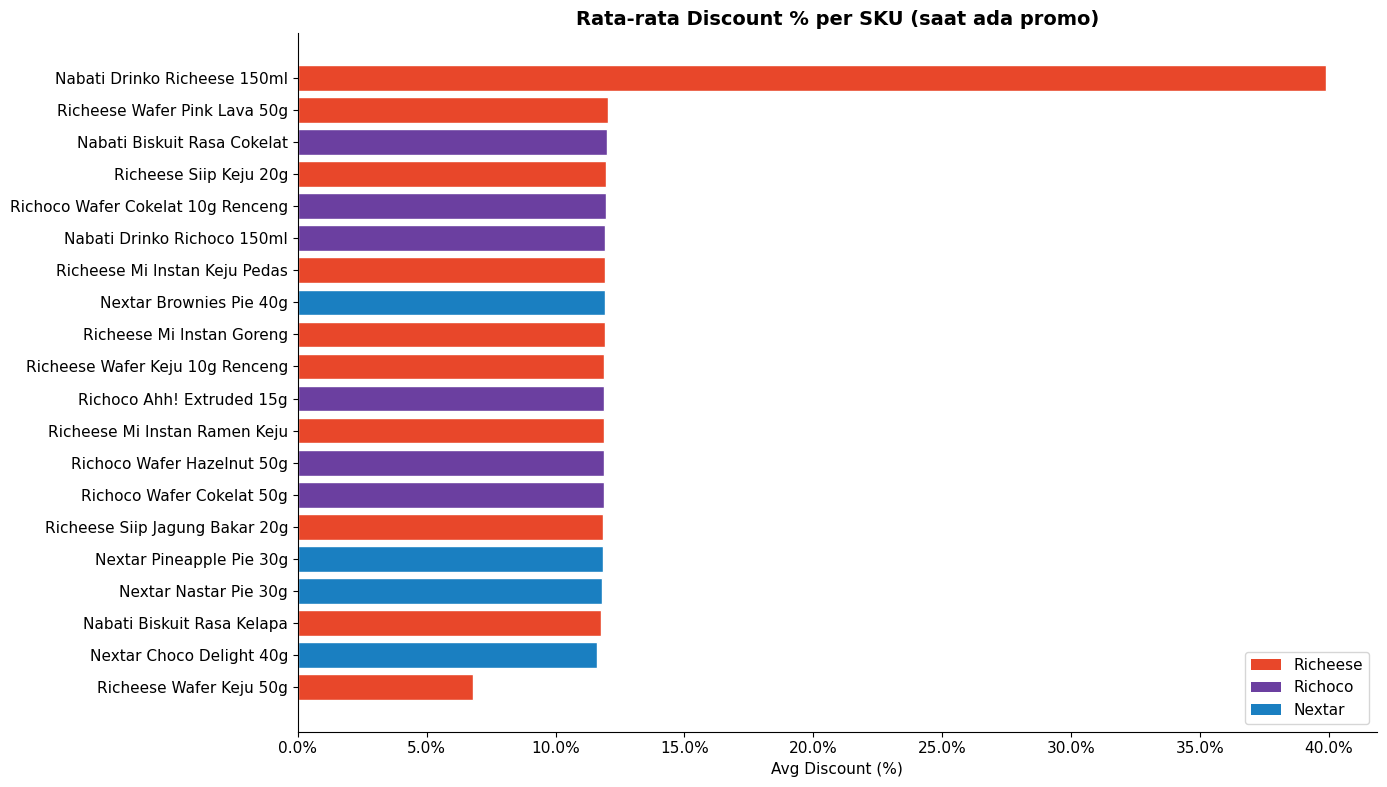

In [12]:
# --- 5B. Rata-rata Discount % per SKU ---
disc_sku = df_full[df_full['DiscountPercentage'] > 0].groupby(
    ['SKU','Brand'])['DiscountPercentage'].mean().reset_index()
disc_sku = disc_sku.sort_values('DiscountPercentage', ascending=True)
colors   = [BRAND_COLORS[b] for b in disc_sku['Brand']]

fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(disc_sku['SKU'], disc_sku['DiscountPercentage'] * 100, color=colors, edgecolor='white')
ax.set_title('Rata-rata Discount % per SKU (saat ada promo)', fontsize=14, fontweight='bold')
ax.set_xlabel('Avg Discount (%)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

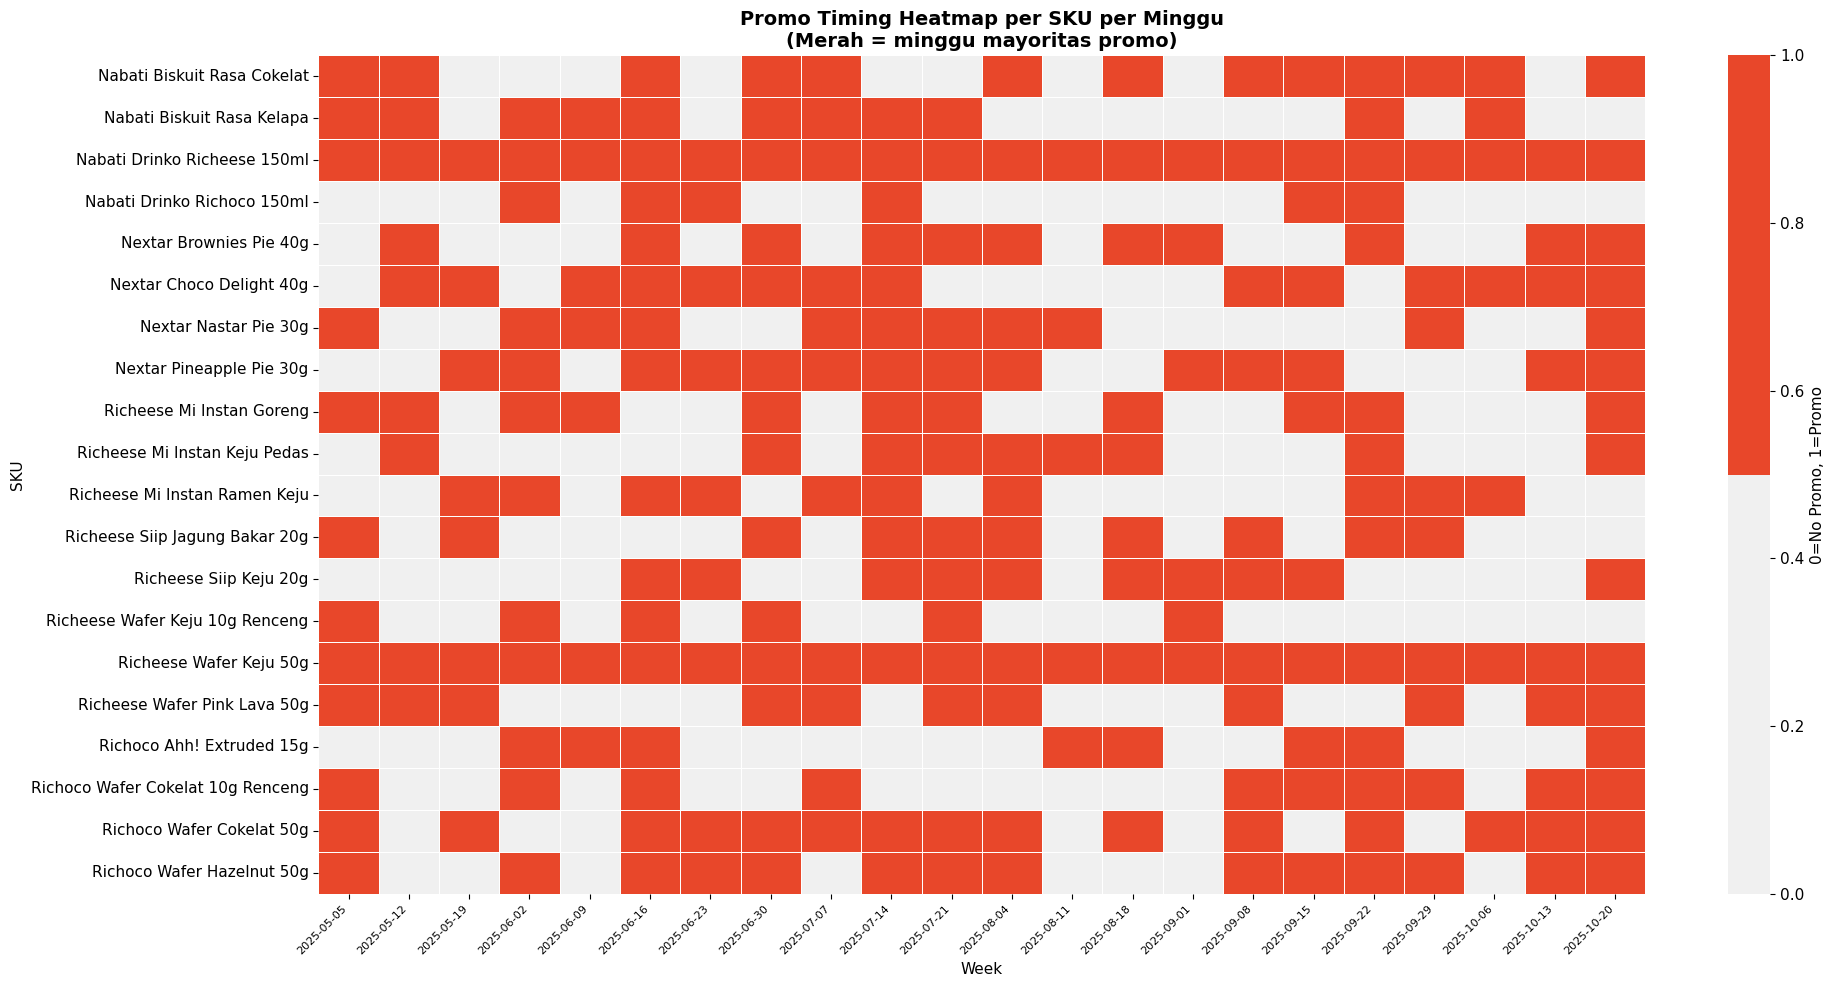


💡 Perhatikan SKU yang sering promo bersamaan — kandidat cannibalization!


In [13]:
# --- 5C. Promo Timing Heatmap per SKU per Minggu ---
promo_heatmap = weekly.pivot(index='SKU', columns='Week', values='promo_flag')
promo_heatmap.columns = [str(c)[:10] for c in promo_heatmap.columns]

fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(
    promo_heatmap,
    cmap=['#F0F0F0','#E8472A'],
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': '0=No Promo, 1=Promo'},
    ax=ax
)
ax.set_title('Promo Timing Heatmap per SKU per Minggu\n'
             '(Merah = minggu mayoritas promo)', fontsize=14, fontweight='bold')
ax.set_xlabel('Week')
ax.set_ylabel('SKU')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

print('\n💡 Perhatikan SKU yang sering promo bersamaan — kandidat cannibalization!')

## 6. Sales Uplift vs Baseline

In [14]:
# hitung baseline (median qty saat no promo per SKU)
baseline = (
    weekly[weekly['promo_flag'] == 0]
    .groupby('SKU_ID')['total_qty']
    .median()
    .rename('baseline_qty')
)

weekly = weekly.merge(baseline, on='SKU_ID', how='left')

# fallback untuk SKU yang tidak punya no-promo weeks
sku_no_baseline = weekly[weekly['baseline_qty'].isna()]['SKU_ID'].unique()
for sku in sku_no_baseline:
    fallback = weekly[weekly['SKU_ID'] == sku]['total_qty'].median()
    weekly.loc[weekly['SKU_ID'] == sku, 'baseline_qty'] = fallback

weekly['uplift_pct'] = ((weekly['total_qty'] - weekly['baseline_qty'])
                        / weekly['baseline_qty'] * 100)

print('✅ Baseline calculated')
print(f'SKU yang pakai fallback baseline: {list(sku_no_baseline)}')

✅ Baseline calculated
SKU yang pakai fallback baseline: ['S001', 'S013']


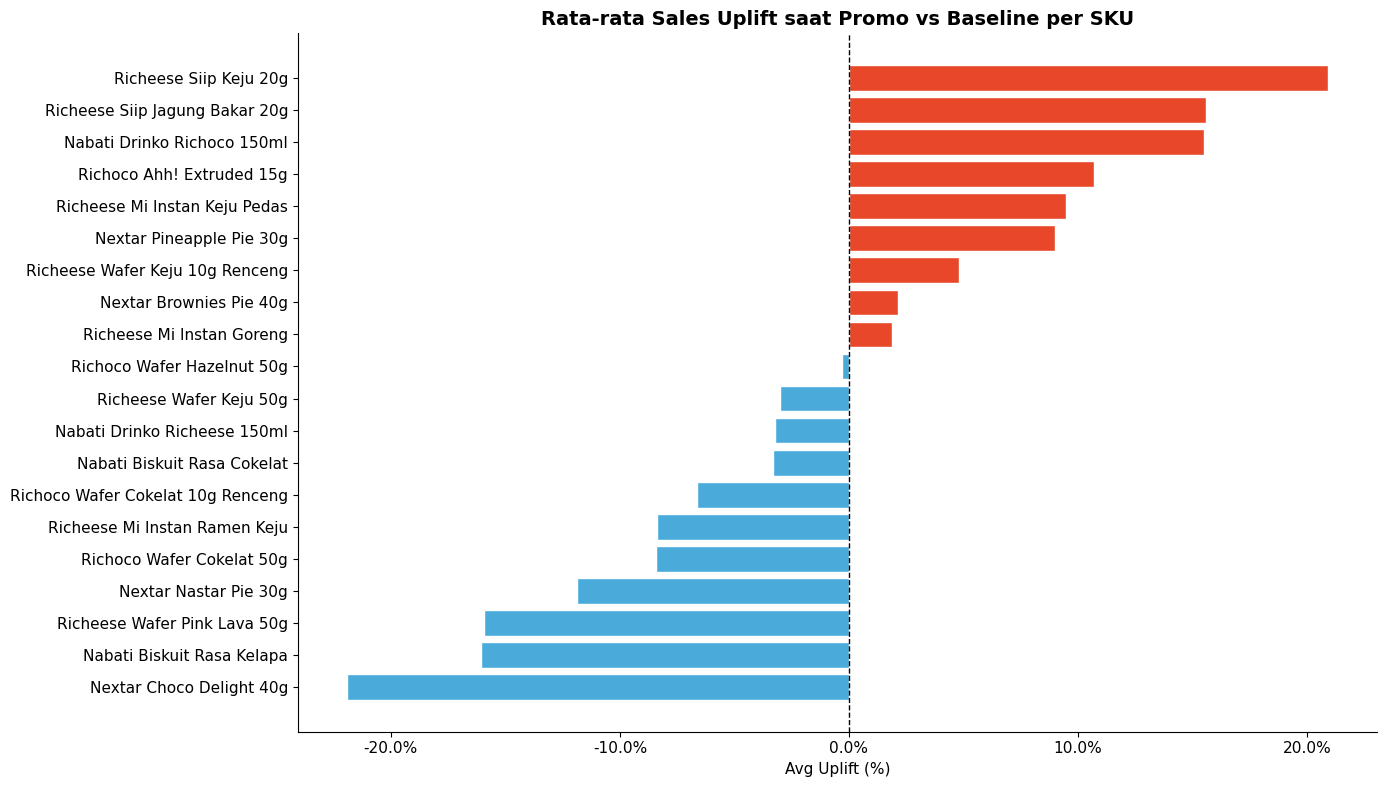


💡 SKU dengan uplift NEGATIF saat promo = potential victim of cannibalization


In [15]:
# --- 6A. Avg Uplift saat Promo vs No Promo per SKU ---
uplift_summary = weekly.groupby(['SKU','Brand','promo_flag'])['uplift_pct'].mean().reset_index()
uplift_promo   = uplift_summary[uplift_summary['promo_flag'] == 1].sort_values('uplift_pct')

colors = ['#E8472A' if v > 0 else '#4AABDB' for v in uplift_promo['uplift_pct']]

fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(uplift_promo['SKU'], uplift_promo['uplift_pct'], color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=1, linestyle='--')
ax.set_title('Rata-rata Sales Uplift saat Promo vs Baseline per SKU',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Avg Uplift (%)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
plt.tight_layout()
plt.show()

print('\n💡 SKU dengan uplift NEGATIF saat promo = potential victim of cannibalization')

## 7. Kandidat Pasangan Cannibalization

In [16]:
# --- 7A. Concurrent Promo Analysis ---
# Hitung berapa minggu 2 SKU promo di waktu yang sama (dalam brand yang sama)

# pivot: baris = week, kolom = SKU, nilai = promo_flag
promo_pivot_w = weekly.pivot(index='Week', columns='SKU_ID', values='promo_flag').fillna(0)

# metadata SKU
sku_meta = weekly[['SKU_ID','SKU','Brand','SKU_Category']].drop_duplicates()

cannib_candidates = []

# hanya pasangan dalam brand yang sama
for brand in weekly['Brand'].unique():
    brand_skus = sku_meta[sku_meta['Brand'] == brand]['SKU_ID'].tolist()
    
    for sku_a, sku_b in combinations(brand_skus, 2):
        if sku_a not in promo_pivot_w.columns or sku_b not in promo_pivot_w.columns:
            continue
        
        total_weeks  = len(promo_pivot_w)
        
        # minggu A promo, B tidak
        a_promo_b_no = ((promo_pivot_w[sku_a] == 1) & (promo_pivot_w[sku_b] == 0)).sum()
        # minggu B promo, A tidak
        b_promo_a_no = ((promo_pivot_w[sku_b] == 1) & (promo_pivot_w[sku_a] == 0)).sum()
        # minggu keduanya promo bersamaan
        both_promo   = ((promo_pivot_w[sku_a] == 1) & (promo_pivot_w[sku_b] == 1)).sum()
        
        # rata-rata uplift A saat B promo
        weeks_b_promo = promo_pivot_w[promo_pivot_w[sku_b] == 1].index
        uplift_a_when_b_promo = weekly[
            (weekly['SKU_ID'] == sku_a) & (weekly['Week'].isin(weeks_b_promo))
        ]['uplift_pct'].mean()
        
        # rata-rata uplift B saat A promo
        weeks_a_promo = promo_pivot_w[promo_pivot_w[sku_a] == 1].index
        uplift_b_when_a_promo = weekly[
            (weekly['SKU_ID'] == sku_b) & (weekly['Week'].isin(weeks_a_promo))
        ]['uplift_pct'].mean()
        
        sku_a_name = sku_meta[sku_meta['SKU_ID'] == sku_a]['SKU'].values[0]
        sku_b_name = sku_meta[sku_meta['SKU_ID'] == sku_b]['SKU'].values[0]
        cat_a      = sku_meta[sku_meta['SKU_ID'] == sku_a]['SKU_Category'].values[0]
        cat_b      = sku_meta[sku_meta['SKU_ID'] == sku_b]['SKU_Category'].values[0]
        same_cat   = cat_a == cat_b
        
        cannib_candidates.append({
            'Brand'               : brand,
            'SKU_A'               : sku_a_name,
            'SKU_B'               : sku_b_name,
            'Same_Category'       : same_cat,
            'Weeks_A_Promo_B_No'  : int(a_promo_b_no),
            'Weeks_B_Promo_A_No'  : int(b_promo_a_no),
            'Weeks_Both_Promo'    : int(both_promo),
            'Uplift_A_when_B_Promo': round(uplift_a_when_b_promo, 2),
            'Uplift_B_when_A_Promo': round(uplift_b_when_a_promo, 2),
        })

cand_df = pd.DataFrame(cannib_candidates)

# cannibalization signal:
# ketika A promo → B turun (negatif), atau ketika B promo → A turun (negatif)
cand_df['Cannib_Signal_A_on_B'] = cand_df['Uplift_B_when_A_Promo'] < -5  # B turun >5% saat A promo
cand_df['Cannib_Signal_B_on_A'] = cand_df['Uplift_A_when_B_Promo'] < -5  # A turun >5% saat B promo
cand_df['Any_Cannib_Signal']    = cand_df['Cannib_Signal_A_on_B'] | cand_df['Cannib_Signal_B_on_A']

print(f'Total pasangan dalam brand yang sama: {len(cand_df)}')
print(f'Pasangan dengan cannibalization signal: {cand_df["Any_Cannib_Signal"].sum()}')
print()
print('=== Top Kandidat Cannibalization (filter same category) ===')
top_cands = cand_df[cand_df['Same_Category'] == True].sort_values(
    ['Uplift_B_when_A_Promo','Uplift_A_when_B_Promo']
).head(20)
print(top_cands[['Brand','SKU_A','SKU_B','Uplift_A_when_B_Promo',
                  'Uplift_B_when_A_Promo','Weeks_A_Promo_B_No',
                  'Weeks_B_Promo_A_No']].to_string(index=False))

Total pasangan dalam brand yang sama: 66
Pasangan dengan cannibalization signal: 30

=== Top Kandidat Cannibalization (filter same category) ===
   Brand                             SKU_A                             SKU_B  Uplift_A_when_B_Promo  Uplift_B_when_A_Promo  Weeks_A_Promo_B_No  Weeks_B_Promo_A_No
  Nextar             Nextar Nastar Pie 30g          Nextar Choco Delight 40g                 -17.18                 -16.80                   5                   8
  Nextar           Nextar Brownies Pie 40g          Nextar Choco Delight 40g                  -8.20                 -12.74                   5                   8
  Nextar           Nextar Brownies Pie 40g             Nextar Nastar Pie 30g                  -5.16                  -7.92                   6                   6
 Richoco         Richoco Wafer Cokelat 50g Richoco Wafer Cokelat 10g Renceng                  -5.81                  -7.87                   8                   3
Richeese           Richeese Wafer Keju 5

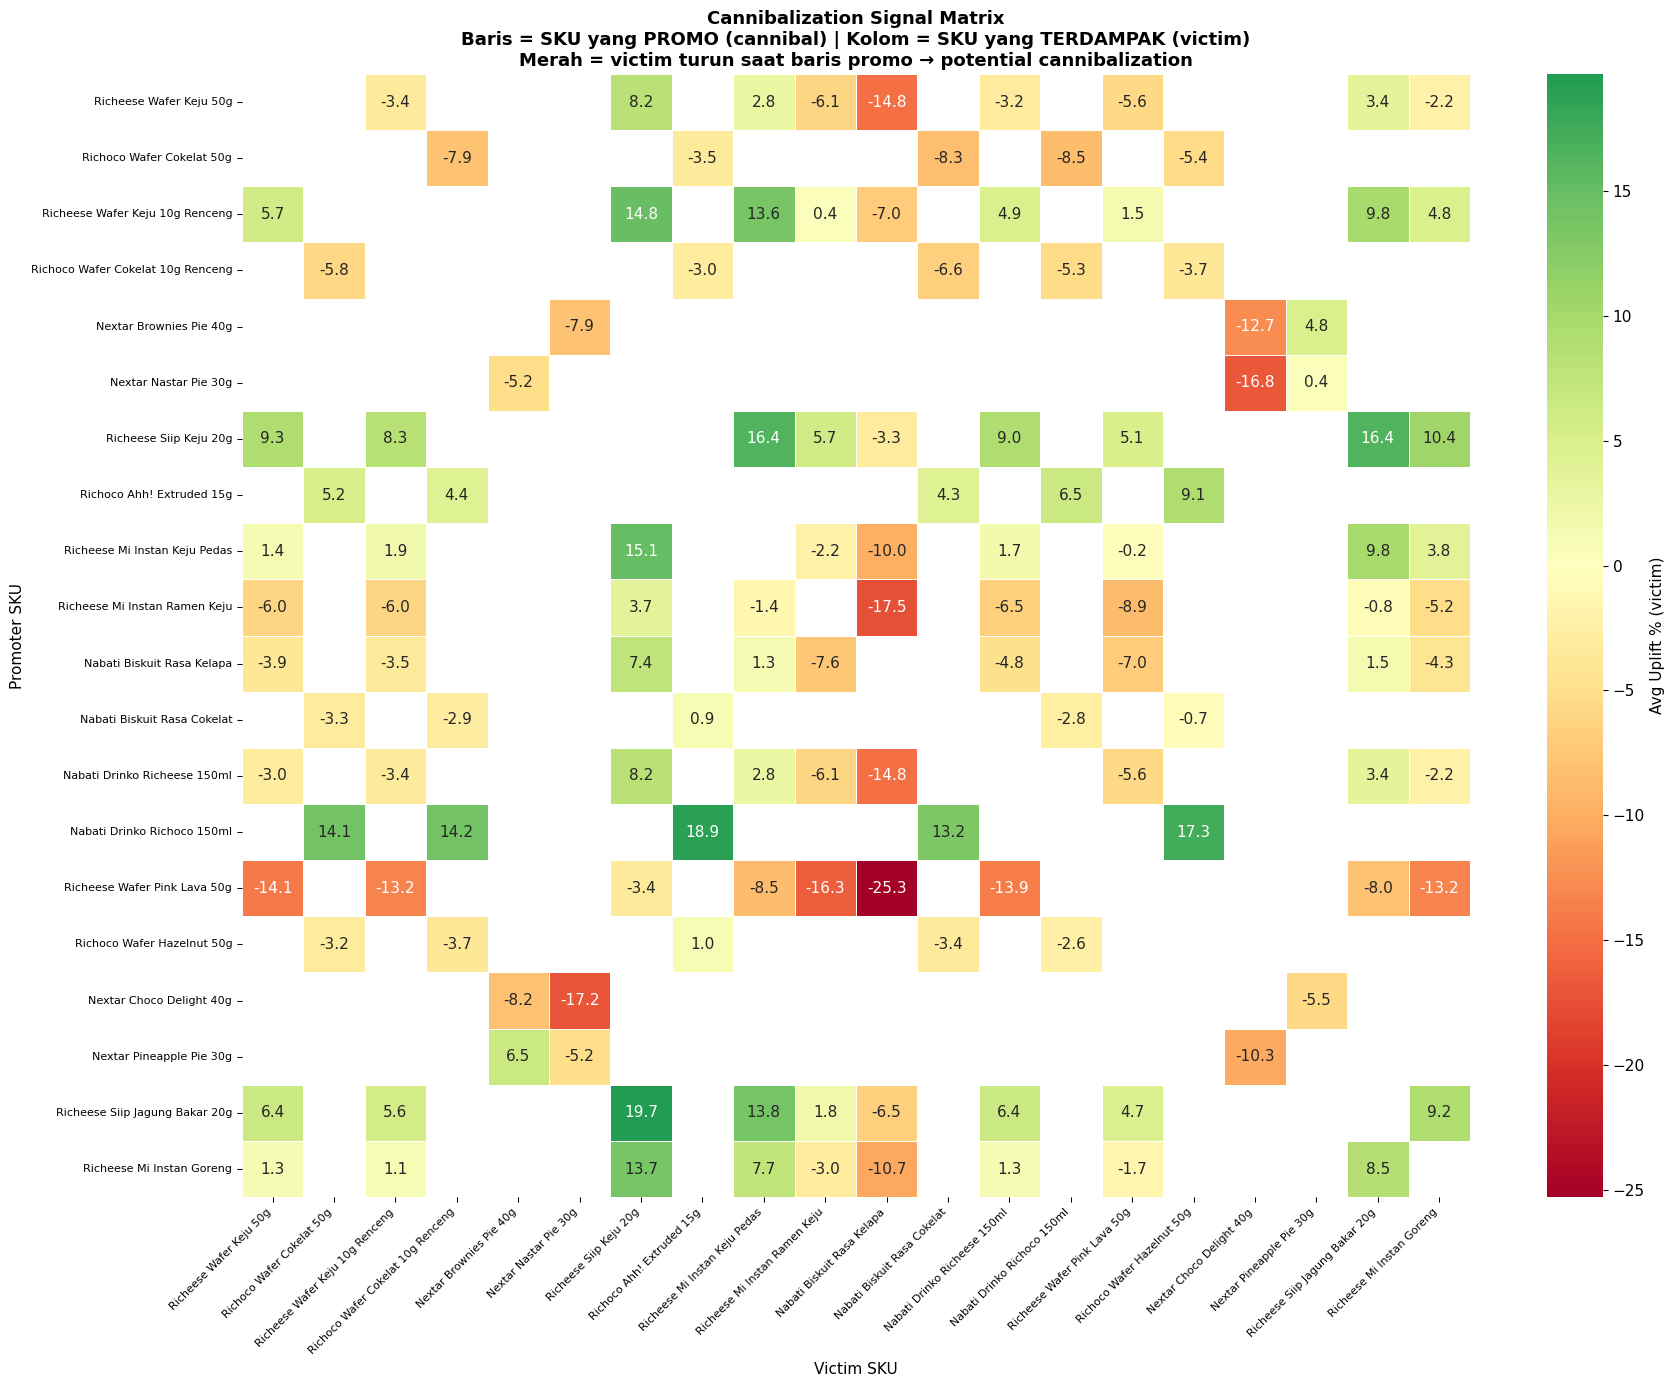


💡 Sel merah = ketika baris (promoter) promo, kolom (victim) sales-nya turun dari baseline
   Fokus pada pasangan dalam brand yang sama untuk cannibalization analysis


In [17]:
# --- 7B. Cannibalization Signal Heatmap (Uplift B saat A promo) ---
# Matrix: baris = SKU yang promo (cannibal), kolom = SKU yang terdampak (victim)

# buat matrix uplift: baris = promoter, kolom = impacted
all_skus = sorted(weekly['SKU_ID'].unique())
sku_names = {row['SKU_ID']: row['SKU'] for _, row in sku_meta.iterrows()}

matrix_data = {}
for sku_a in all_skus:
    brand_a = sku_meta[sku_meta['SKU_ID'] == sku_a]['Brand'].values[0]
    weeks_a_promo = promo_pivot_w[promo_pivot_w[sku_a] == 1].index
    row = {}
    for sku_b in all_skus:
        brand_b = sku_meta[sku_meta['SKU_ID'] == sku_b]['Brand'].values[0]
        if sku_a == sku_b or brand_a != brand_b:
            row[sku_b] = np.nan
        else:
            uplift = weekly[
                (weekly['SKU_ID'] == sku_b) & (weekly['Week'].isin(weeks_a_promo))
            ]['uplift_pct'].mean()
            row[sku_b] = round(uplift, 1)
    matrix_data[sku_a] = row

matrix_df = pd.DataFrame(matrix_data).T
matrix_df.index   = [sku_names.get(s, s) for s in matrix_df.index]
matrix_df.columns = [sku_names.get(s, s) for s in matrix_df.columns]

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(
    matrix_df,
    cmap='RdYlGn',
    center=0,
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    linecolor='white',
    mask=matrix_df.isna(),
    cbar_kws={'label': 'Avg Uplift % (victim)'},
    ax=ax
)
ax.set_title(
    'Cannibalization Signal Matrix\n'
    'Baris = SKU yang PROMO (cannibal) | Kolom = SKU yang TERDAMPAK (victim)\n'
    'Merah = victim turun saat baris promo → potential cannibalization',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Victim SKU')
ax.set_ylabel('Promoter SKU')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

print('\n💡 Sel merah = ketika baris (promoter) promo, kolom (victim) sales-nya turun dari baseline')
print('   Fokus pada pasangan dalam brand yang sama untuk cannibalization analysis')

In [18]:
# --- 7C. Ranking Kandidat Cannibalization ---
strong_candidates = cand_df[
    (cand_df['Same_Category'] == True) &
    (cand_df['Any_Cannib_Signal'] == True)
].copy()

# composite score: rata-rata penurunan kedua arah
strong_candidates['avg_negative_impact'] = (
    strong_candidates[['Uplift_A_when_B_Promo', 'Uplift_B_when_A_Promo']]
    .apply(lambda row: min(row['Uplift_A_when_B_Promo'], row['Uplift_B_when_A_Promo']), axis=1)
)
strong_candidates = strong_candidates.sort_values('avg_negative_impact')

print('=== FINAL: Ranked Kandidat Cannibalization (Same Category, Same Brand) ===')
print(strong_candidates[[
    'Brand','SKU_A','SKU_B',
    'Uplift_A_when_B_Promo','Uplift_B_when_A_Promo',
    'avg_negative_impact'
]].to_string(index=False))

# save
strong_candidates.to_csv('../data/cannibalization_candidates.csv', index=False)
weekly.to_csv('../data/weekly_aggregated.csv', index=False)
print('\n✅ EDA selesai! Files saved:')
print('   - ../data/weekly_aggregated.csv')
print('   - ../data/cannibalization_candidates.csv')

=== FINAL: Ranked Kandidat Cannibalization (Same Category, Same Brand) ===
   Brand                           SKU_A                             SKU_B  Uplift_A_when_B_Promo  Uplift_B_when_A_Promo  avg_negative_impact
  Nextar           Nextar Nastar Pie 30g          Nextar Choco Delight 40g                 -17.18                 -16.80               -17.18
Richeese         Richeese Wafer Keju 50g      Richeese Wafer Pink Lava 50g                 -14.06                  -5.58               -14.06
Richeese Richeese Wafer Keju 10g Renceng      Richeese Wafer Pink Lava 50g                 -13.22                   1.52               -13.22
  Nextar         Nextar Brownies Pie 40g          Nextar Choco Delight 40g                  -8.20                 -12.74               -12.74
  Nextar        Nextar Choco Delight 40g          Nextar Pineapple Pie 30g                 -10.27                  -5.50               -10.27
  Nextar         Nextar Brownies Pie 40g             Nextar Nastar Pie 30